### Calculation of Carbon contract for Difference (CCfD)-price

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [119]:
## Manually Input varibles 

# fossil based methanol data
energy_density = 19.7*10**9                               # J/t  (source: https://ebookcentral.proquest.com/lib/kbhnhh-ebooks/detail.action?docID=5116604)   
co2_indstr_perJ = 90 * 10**(-9)                           # kg*CO2/J  (source: https://www.methanol.org/wp-content/uploads/2022/01/CARBON-FOOTPRINT-OF-METHANOL-PAPER_1-31-22.pdf)

# Average emissions of grid power
avg_elctr_emissions_2019 = 372/(10**6)                    # kg Co2/(Wh electricity)  (source: https://energinet.dk/media/1duf3x0o/19_07249-24-generel-eldeklaration-historik-10536640_5986882_0.xlsx)
avg_elctr_emissions_2020 = 478.5/(10**6)                  # kg Co2/(Wh electricity)  (source: https://energinet.dk/media/1duf3x0o/19_07249-24-generel-eldeklaration-historik-10536640_5986882_0.xlsx)
avg_elctr_emissions_2021 = 411.5/(10**6)                  # kg Co2/(Wh electricity)  (source: https://energinet.dk/media/1duf3x0o/19_07249-24-generel-eldeklaration-historik-10536640_5986882_0.xlsx)
avg_elctr_emissions_2022 = 432.0/(10**6)                  # kg Co2/(Wh electricity)  (source: https://energinet.dk/media/1duf3x0o/19_07249-24-generel-eldeklaration-historik-10536640_5986882_0.xlsx)
avg_elctr_emissions_2023 = 499.8/(10**6)                  # kg Co2/(Wh electricity)  (source: https://energinet.dk/media/1duf3x0o/19_07249-24-generel-eldeklaration-historik-10536640_5986882_0.xlsx)


# Power distribution within the hub for years 2019-2023
Production_PV_2019 = 378628                              # MWh (own result)
El_from_grid_2019 = 193797.8                             # MWh (own result)
El_to_grid_2019 = 246822.1                               # MWh (own result)

Production_PV_2020 = 111111.1111                         # MWh (own result)
El_from_grid_2020 = 111111.1111                          # MWh (own result)
El_to_grid_2020 = 111111.1111                            # MWh (own result)

Production_PV_2021 = 111111.1111                         # MWh (own result)
El_from_grid_2021 = 111111.1111                         # MWh (own result)
El_to_grid_2021 = 111111.1111                            # MWh (own result)

Production_PV_2022 = 111111.1111                         # MWh (own result)
El_from_grid_2022 = 111111.1111                         # MWh (own result)
El_to_grid_2022 = 111111.1111                            # MWh (own result)

Production_PV_2023 = 360342.6432                         # MWh (own result)
El_from_grid_2023 = 193838.1675                          # MWh (own result)
El_to_grid_2023 = 228661.1283                            # MWh (own result)

# Yearly methanol demand in hub
demand_yearly_t = 32000                                  # t/a    (own result)

# Costs in €/t
costs_hub_2019 = 1415.7                                  # €/t    (own result)
costs_hub_2020 = 1111.11                                 # €/t    (own result)
costs_hub_2021 = 1111.11                                  # €/t    (own result)
costs_hub_2022 = 1111.11                                  # €/t    (own result)
costs_hub_2023 = 1073.99                                 # €/t    (own result)
costs_hub_2050 = 755.99                                  # €/t    (own result)

# Costs industrial methanol 2019-2023   (To add for the years 2020-2022!!!)
costs_indstr_methanol2019 = 370                          # $/t    (source: https://www.irena.org/-/media/Files/IRENA/Agency/Publication/2021/Jan/IRENA_Innovation_Renewable_Methanol_2021.pdf)
costs_indstr_methanol2020 = 205                          # $/t    (source: https://www.irena.org/-/media/Files/IRENA/Agency/Publication/2021/Jan/IRENA_Innovation_Renewable_Methanol_2021.pdf)
costs_indstr_methanol2021 = 111                          # $/t    (source: https://shipandbunker.com/prices/emea/nwe/nl-rtm-rotterdam)
costs_indstr_methanol2022 = 111                          # $/t    (source: https://shipandbunker.com/prices/emea/nwe/nl-rtm-rotterdam)
costs_indstr_methanol2023 = 574.5                        # $/t    (source: https://shipandbunker.com/prices/emea/nwe/nl-rtm-rotterdam)
exchange_rate2019 = 0.8932                               # €/$    (source: https://www.ecb.europa.eu/stats/policy_and_exchange_rates/euro_reference_exchange_rates/html/eurofxref-graph-usd.en.html)
exchange_rate2020 = 0.1111                               # €/$    (source: https://www.ecb.europa.eu/stats/policy_and_exchange_rates/euro_reference_exchange_rates/html/eurofxref-graph-usd.en.html)
exchange_rate2021 = 0.1111                               # €/$    (source: https://www.ecb.europa.eu/stats/policy_and_exchange_rates/euro_reference_exchange_rates/html/eurofxref-graph-usd.en.html)
exchange_rate2022 = 0.1111                               # €/$    (source: https://www.ecb.europa.eu/stats/policy_and_exchange_rates/euro_reference_exchange_rates/html/eurofxref-graph-usd.en.html)
exchange_rate2023 = 0.9248                               # €/$    (source: https://www.ecb.europa.eu/stats/policy_and_exchange_rates/euro_reference_exchange_rates/html/eurofxref-graph-usd.en.html)


# European allowances 2019-2023
avg_EUA_2019 = 24.723125       # €/(t*CO2-eq)  (source: https://icapcarbonaction.com/en/ets-prices)
avg_EUA_2020 = 24.38660287     # €/(t*CO2-eq)  (source: https://icapcarbonaction.com/en/ets-prices)
avg_EUA_2021 = 54.15156951     # €/(t*CO2-eq)  (source: https://icapcarbonaction.com/en/ets-prices)
avg_EUA_2022 = 80.18404545     # €/(t*CO2-eq)  (source: https://icapcarbonaction.com/en/ets-prices)
avg_EUA_2023 = 83.59650224     # €/(t*CO2-eq)  (source: https://icapcarbonaction.com/en/ets-prices)

EUA_2050_dkk = 1652            # DKK/t*co2-eq. (source: https://fm.dk/media/4tkj2o4w/noegletalskatalog_juni-2024.pdf)
exchange_rate = 0.1338
EUA_2050_EUR = EUA_2050_dkk*exchange_rate


In [120]:
## Further calculations

# Co2 equivalent fossil based methanol production 
#co2_equiv_perkg = 1.8                                  # t*CO2-eq/(t Methanol)   (source: ecoinvent data)
#co2_equiv_perJ  = co2_equiv_perkg/energy_density
co2_industr_perWh = co2_indstr_perJ*3600                  # kg*CO2-eq/Wh

# Emissions per Wh
avg_emissions_indstr_methanol = co2_industr_perWh         # kg Co2/(Wh methanol)


# Electricity used for production, PV share and used grid electricity in production 
#2019
El_used2019 = El_from_grid_2019+Production_PV_2019- El_to_grid_2019      # MWh 
PV_used_rel2019 = (Production_PV_2019-El_to_grid_2019)/El_used2019       # % 
el_demand_grid_2019 = El_from_grid_2019*(1-PV_used_rel2019)              # MWh

#2020
El_used2020 = El_from_grid_2020+Production_PV_2020- El_to_grid_2020      # MWh 
PV_used_rel2020 = (Production_PV_2020-El_to_grid_2020)/El_used2020       # % 
el_demand_grid_2020 = El_from_grid_2020*(1-PV_used_rel2020)              # MWh

#2021
El_used2021 = El_from_grid_2021+Production_PV_2021- El_to_grid_2021      # MWh 
PV_used_rel2021 = (Production_PV_2021-El_to_grid_2021)/El_used2021       # % 
el_demand_grid_2021 = El_from_grid_2021*(1-PV_used_rel2021)              # MWh

#2022
El_used2022 = El_from_grid_2022+Production_PV_2022- El_to_grid_2022      # MWh 
PV_used_rel2022 = (Production_PV_2022-El_to_grid_2022)/El_used2022       # % 
el_demand_grid_2022 = El_from_grid_2022*(1-PV_used_rel2022)              # MWh

#2023
El_used2023 = El_from_grid_2023+Production_PV_2023- El_to_grid_2023      # MWh 
PV_used_rel2023 = (Production_PV_2023-El_to_grid_2023)/El_used2023       # % 
el_demand_grid_2023 = El_from_grid_2023*(1-PV_used_rel2023)              # MWh


# Electricity taken from the grid 
#2019
grid_electricity_2019 = el_demand_grid_2019 *10**6        # Wh
#2020
grid_electricity_2020 = el_demand_grid_2020 *10**6        # Wh
#2021
grid_electricity_2021 = el_demand_grid_2021 *10**6        # Wh
#2022
grid_electricity_2022 = el_demand_grid_2022 *10**6        # Wh
#2023
grid_electricity_2023 = el_demand_grid_2023 *10**6        # Wh 

# Methanol demand  in hub (yearly, in Wh) 
demand_yearly_Wh = (energy_density*demand_yearly_t)/3600  # Wh/a

# Emissions per year 
emissions_hub_2019 = grid_electricity_2019*avg_elctr_emissions_2019/1000       # t Co2
emissions_hub_2020 = grid_electricity_2020*avg_elctr_emissions_2020/1000       # t Co2
emissions_hub_2021 = grid_electricity_2021*avg_elctr_emissions_2021/1000       # t Co2
emissions_hub_2022 = grid_electricity_2022*avg_elctr_emissions_2022/1000       # t Co2
emissions_hub_2023 = grid_electricity_2023*avg_elctr_emissions_2023/1000       # t Co2
emissions_indstrM = demand_yearly_Wh*avg_emissions_indstr_methanol/1000        # t Co2
emissions_hub_2050 = 0


# Emissions per tonne Methanol
emissions_per_tonne_2019 = emissions_hub_2019/demand_yearly_t
emissions_per_tonne_2020 = emissions_hub_2020/demand_yearly_t
emissions_per_tonne_2021 = emissions_hub_2021/demand_yearly_t
emissions_per_tonne_2022 = emissions_hub_2022/demand_yearly_t
emissions_per_tonne_2023 = emissions_hub_2023/demand_yearly_t
emissions_per_tonne_indstrl = emissions_indstrM/demand_yearly_t

# Costs for yearly demand
ym_costs_2019 = costs_hub_2019*demand_yearly_t                                        # €
ym_costs_2020 = costs_hub_2020*demand_yearly_t                                        # €
ym_costs_2021 = costs_hub_2021*demand_yearly_t                                        # €
ym_costs_2022 = costs_hub_2022*demand_yearly_t                                        # €
ym_costs_2023 = costs_hub_2023*demand_yearly_t                                        # €
ym_costs_2050 = costs_hub_2050*demand_yearly_t                                        # €
ym_costs_indstr2019 = costs_indstr_methanol2019*exchange_rate2019*demand_yearly_t     # €
ym_costs_indstr2020 = costs_indstr_methanol2020*exchange_rate2020*demand_yearly_t     # €
ym_costs_indstr2021 = costs_indstr_methanol2021*exchange_rate2021*demand_yearly_t     # €
ym_costs_indstr2022 = costs_indstr_methanol2022*exchange_rate2022*demand_yearly_t     # €
ym_costs_indstr2023 = costs_indstr_methanol2023*exchange_rate2023*demand_yearly_t     # €
ym_costs_indstr2050 = ym_costs_indstr2023

# Calculations of neccessary carbon prices   (extra costs per saved tonne of co2)
CP2019 = (ym_costs_2019-ym_costs_indstr2019)/(emissions_indstrM-emissions_hub_2019)
CP2020 = (ym_costs_2020-ym_costs_indstr2020)/(emissions_indstrM-emissions_hub_2020)
CP2021 = (ym_costs_2021-ym_costs_indstr2021)/(emissions_indstrM-emissions_hub_2021)
CP2022 = (ym_costs_2022-ym_costs_indstr2022)/(emissions_indstrM-emissions_hub_2022)
CP2023 = (ym_costs_2023-ym_costs_indstr2023)/(emissions_indstrM-emissions_hub_2023)
CP2050 = (ym_costs_2050-ym_costs_indstr2050)/(emissions_indstrM-emissions_hub_2050)

In [121]:
print("Carbon price:", CP2019, CP2020,CP2021,CP2022,CP2023, CP2050)
print("CO2-equivalent:", emissions_per_tonne_2019, emissions_per_tonne_2023, emissions_per_tonne_indstrl)

Carbon price: 2511.581090006087 9850.829122420508 3192.446179216236 4024.827470316022 -18210.99754331758 126.73006204173716
CO2-equivalent: 1.3409152051597233 1.802800256614671 1.7730000000000004


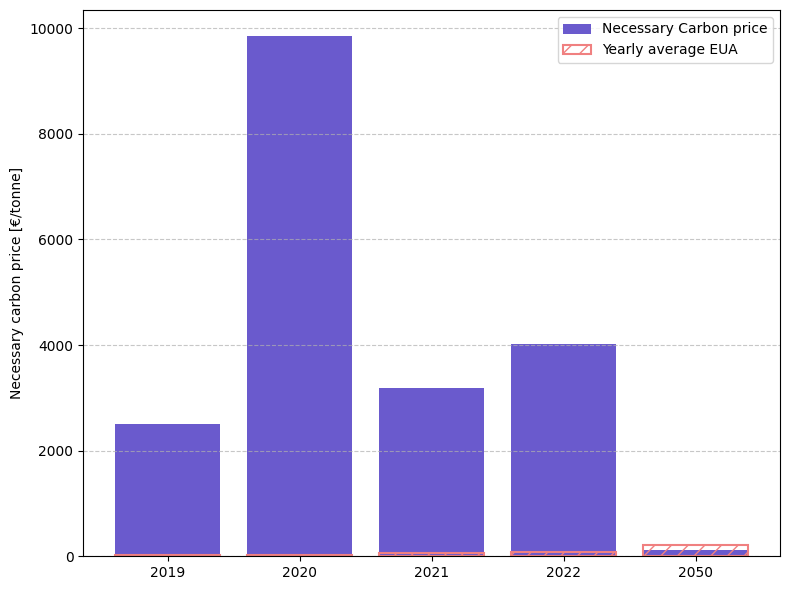

In [122]:
# Bar positions
x_pos = np.arange(5)
EUAs = [avg_EUA_2019, avg_EUA_2020, avg_EUA_2021, avg_EUA_2022, EUA_2050_EUR]
# Plot
plt.figure(figsize=(8, 6))

# Stacked bar plot
plt.bar(x_pos, [CP2019,CP2020,CP2021,CP2022, CP2050], color='#6A5ACD', label='Necessary Carbon price')
plt.bar(x_pos, EUAs, color='none', edgecolor='lightcoral', hatch='//', linewidth=1.5, label='Yearly average EUA')

# Adding labels and formatting
plt.xticks(x_pos, [2019, 2020, 2021, 2022, 2050])
plt.ylabel('Necessary carbon price [€/tonne]')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show plot
plt.savefig("carbon_price_netgrid.png")
plt.tight_layout()
plt.show()

C:\Users\luc.eco\AppData\Local\Temp\ipykernel_7420\3646737451.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


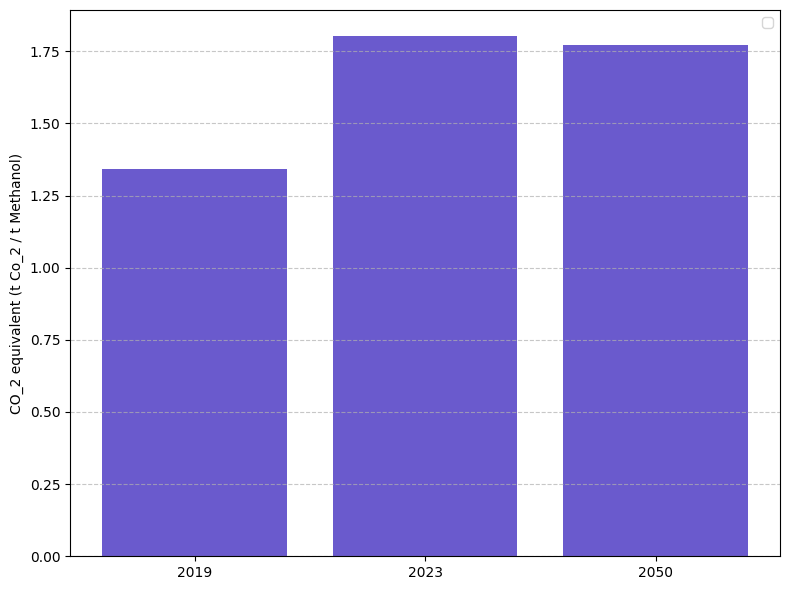

In [118]:
# Bar positions
x_pos = np.arange(3)
# Plot
plt.figure(figsize=(8, 6))

# Stacked bar plot
plt.bar(x_pos, [emissions_per_tonne_2019, emissions_per_tonne_2023, emissions_per_tonne_indstrl], color='#6A5ACD')

# Adding labels and formatting
plt.xticks(x_pos, [2019, 2023, 2050])
plt.ylabel('CO_2 equivalent (t Co_2 / t Methanol)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show plot
plt.savefig("carbon_price_netgrid.png")
plt.tight_layout()
plt.show()

In [19]:
avg_EUA_2019 = 24.723125       #€/(t*CO2-eq)  (https://icapcarbonaction.com/en/ets-prices)
avg_EUA_2020 = 24.38660287     #€/(t*CO2-eq)
avg_EUA_2021 = 54.15156951     #€/(t*CO2-eq)
avg_EUA_2022 = 80.18404545     #€/(t*CO2-eq)
avg_EUA_2023 = 83.59650224     #€/(t*CO2-eq)

EUA_2024_2050_DKK = np.array([537, 559, 583, 607, 633, 661, 690, 722, 756, 792, 831, 871, 914, 960, 1008, 1059, 1113, 1171, 1232, 1297, 1366, 1440, 1518, 1601, 1689, 1783, 1652])
# https://fm.dk/media/4tkj2o4w/noegletalskatalog_juni-2024.pdf
exchange_rate = 0.1338
EUA_2024_2050_EUR = EUA_2024_2050_DKK * exchange_rate
EUA_2023_2050_EUR = np.insert(EUA_2024_2050_EUR,0, avg_EUA_2023)
EUA_2019_2024_EUR = np.array([avg_EUA_2019, avg_EUA_2020, avg_EUA_2021, avg_EUA_2022, avg_EUA_2023])
EUA_all = np.concatenate((np.array([avg_EUA_2019, avg_EUA_2020, avg_EUA_2021, avg_EUA_2022, avg_EUA_2023]), EUA_2024_2050_EUR), axis=None)


In [37]:
# methanol data for calculations
demand_daily_Wh = 20.1928*10**6                          # Wh
price_methanol = 277.8
#price_methanol = 360                                     # €/tonne        (https://www.methanex.com/sites/default/files/methanol-price/Mx-Price-Sheet%20-%20Jan%2029%2C%202019.pdf)
energy_density = 19.7*10**9                              # J/tonne     
co2_equiv_perkg = 0.723                                  # kg*CO2-eq/(kg Methanol)
co2_equiv_perJ = co2_equiv_perkg/energy_density          # t*CO2-eq/J
print(co2_equiv_perJ)
emissions_of_hub = 0

# Daily demand
demand_daily_J = demand_daily_Wh*3600
demand_daily_t = demand_daily_J/energy_density

# CO2-eq. per daily methanol and per tonne methanol
co2_per_day = co2_equiv * demand_daily_J
co2_per_tonne = co2_per_day / demand_daily_t

# Methanol price excluding CO2 price to have the production costs
costs_methanol = price_methanol - avg_EUA_2019* co2_per_tonne    # €/tonne
daily_costs_conventional_M = costs_methanol * demand_daily_t           # €

# Costs for modelled methanol per day without PV revnue
#daily_costs_renewable_M_2019 = LCOE_t * demand_daily_t                       #€
daily_costs_renewable_M_2019 = 1415.7 * demand_daily_t                        #€
daily_costs_renewable_M_2050 = 962.54 * demand_daily_t                        #€

# Costs for modelled methanol per day with PV revnue
daily_costs_renewable_M_2019_PV = 1121.11 * demand_daily_t                        #€
daily_costs_renewable_M_2050_PV = 755.99 * demand_daily_t                        #€


# Cost and Emission differences 
Delta_costs_2019 = daily_costs_renewable_M_2019 - daily_costs_conventional_M
Delta_costs_2050 = daily_costs_renewable_M_2050 - daily_costs_conventional_M
Delta_emissions = co2_per_day- emissions_of_hub

# Cost and Emission differences with PV revnue
Delta_costs_2019_PV = daily_costs_renewable_M_2019_PV - daily_costs_conventional_M
Delta_costs_2050_PV = daily_costs_renewable_M_2050_PV - daily_costs_conventional_M
Delta_emissions_PV = co2_per_day- emissions_of_hub

# CCfD price
CCfD_2019 = Delta_costs_2019/Delta_emissions
CCfD_2050 = Delta_costs_2050/Delta_emissions

# CCfD price with PV revenue
CCfD_2019_PV = Delta_costs_2019_PV/Delta_emissions
CCfD_2050_PV = Delta_costs_2050_PV/Delta_emissions

# Necessary CO_2 price for 2050 if no CCfD
LCOE_t_2050 = 962.54
price_per_co2_2050 = -(costs_methanol-LCOE_t_2050)/co2_per_tonne 

print(daily_costs_renewable_M_2019, daily_costs_conventional_M, co2_per_day, CCfD_2019)

3.6700507614213195e-11
5224.010611979696 836.38862285167 7.6328784 574.8318994742567


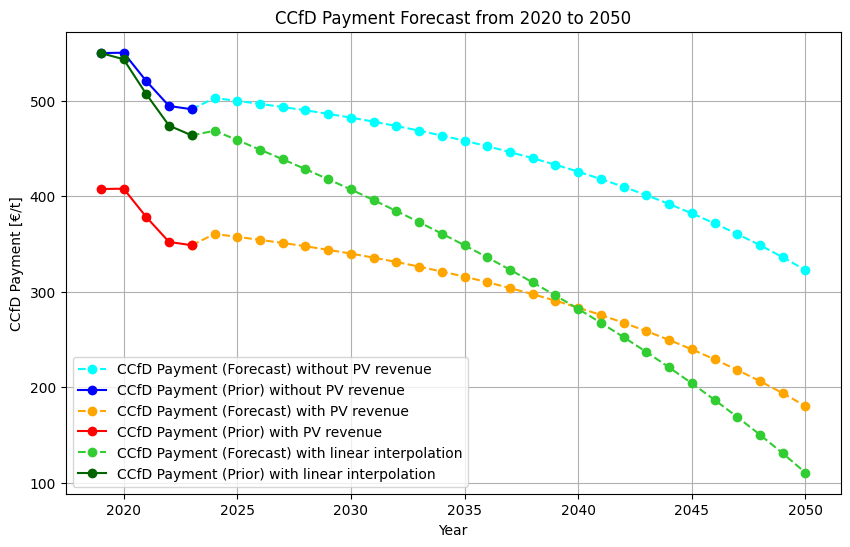

In [17]:
#Plotting CCfD for years 2020-2050
#co2_prices_forecast = np.arange(25, 285, (260/30))

# Without PV
# Array with CCfd of 2019 for every year
CCfD_array_long= np.full(len(EUA_2023_2050_EUR), CCfD_2019)
CCfD_array_short = np.full(len(EUA_2019_2024_EUR), CCfD_2019)

CCfD_payment_forecast = CCfD_array_long - EUA_2023_2050_EUR
CCfD_payment_prior = CCfD_array_short - EUA_2019_2024_EUR

# With PV
# Array with CCfd of 2019 for every year
CCfD_array_long_PV= np.full(len(EUA_2023_2050_EUR), CCfD_2019_PV)
CCfD_array_short_PV = np.full(len(EUA_2019_2024_EUR), CCfD_2019_PV)
CCfD_payment_forecast_PV = CCfD_array_long_PV - EUA_2023_2050_EUR
CCfD_payment_prior_PV = CCfD_array_short_PV - EUA_2019_2024_EUR

# With linear interpolation between CCfD 2019 and 2050
linear_CCfD = np.arange(CCfD_2019, CCfD_2050, ((CCfD_2050-CCfD_2019)/32))
CCfD_array_long_linear= linear_CCfD[4:]
CCfD_array_short_linear = linear_CCfD[:5]
CCfD_payment_forecast_linear = CCfD_array_long_linear - EUA_2023_2050_EUR
CCfD_payment_prior_linear = CCfD_array_short_linear - EUA_2019_2024_EUR

years_prior = np.arange(2019, 2024) 
years_forecast = np.arange(2023, 2051)  # 2023 to 2050


# Plotting the data
plt.figure(figsize=(10, 6))
plt.plot(years_forecast, CCfD_payment_forecast, marker='o', linestyle='--', color='cyan', label="CCfD Payment (Forecast) without PV revenue")
plt.plot(years_prior, CCfD_payment_prior, marker='o', color='blue', label="CCfD Payment (Prior) without PV revenue")

plt.plot(years_forecast, CCfD_payment_forecast_PV, marker='o', linestyle='--', color='orange', label="CCfD Payment (Forecast) with PV revenue")
plt.plot(years_prior, CCfD_payment_prior_PV, marker='o', color='r', label="CCfD Payment (Prior) with PV revenue")

plt.plot(years_forecast, CCfD_payment_forecast_linear, marker='o', linestyle='--', color='limegreen', label="CCfD Payment (Forecast) with linear interpolation")
plt.plot(years_prior, CCfD_payment_prior_linear, marker='o', color='darkgreen', label="CCfD Payment (Prior) with linear interpolation")

plt.xticks(np.arange(2020, 2051, 5))

plt.xlabel("Year")
plt.ylabel("CCfD Payment [€/t]")
plt.title("CCfD Payment Forecast from 2020 to 2050")
plt.legend()
plt.grid(True)
plt.show()



1025.09722964467 5224.010611979696 2.667909636548223 1296.0589211618262
5224.010611979696 836.38862285167


In [42]:
import matplotlib.colors as mcolors
print(mcolors.CSS4_COLORS)

{'aliceblue': '#F0F8FF', 'antiquewhite': '#FAEBD7', 'aqua': '#00FFFF', 'aquamarine': '#7FFFD4', 'azure': '#F0FFFF', 'beige': '#F5F5DC', 'bisque': '#FFE4C4', 'black': '#000000', 'blanchedalmond': '#FFEBCD', 'blue': '#0000FF', 'blueviolet': '#8A2BE2', 'brown': '#A52A2A', 'burlywood': '#DEB887', 'cadetblue': '#5F9EA0', 'chartreuse': '#7FFF00', 'chocolate': '#D2691E', 'coral': '#FF7F50', 'cornflowerblue': '#6495ED', 'cornsilk': '#FFF8DC', 'crimson': '#DC143C', 'cyan': '#00FFFF', 'darkblue': '#00008B', 'darkcyan': '#008B8B', 'darkgoldenrod': '#B8860B', 'darkgray': '#A9A9A9', 'darkgreen': '#006400', 'darkgrey': '#A9A9A9', 'darkkhaki': '#BDB76B', 'darkmagenta': '#8B008B', 'darkolivegreen': '#556B2F', 'darkorange': '#FF8C00', 'darkorchid': '#9932CC', 'darkred': '#8B0000', 'darksalmon': '#E9967A', 'darkseagreen': '#8FBC8F', 'darkslateblue': '#483D8B', 'darkslategray': '#2F4F4F', 'darkslategrey': '#2F4F4F', 'darkturquoise': '#00CED1', 'darkviolet': '#9400D3', 'deeppink': '#FF1493', 'deepskyblue'

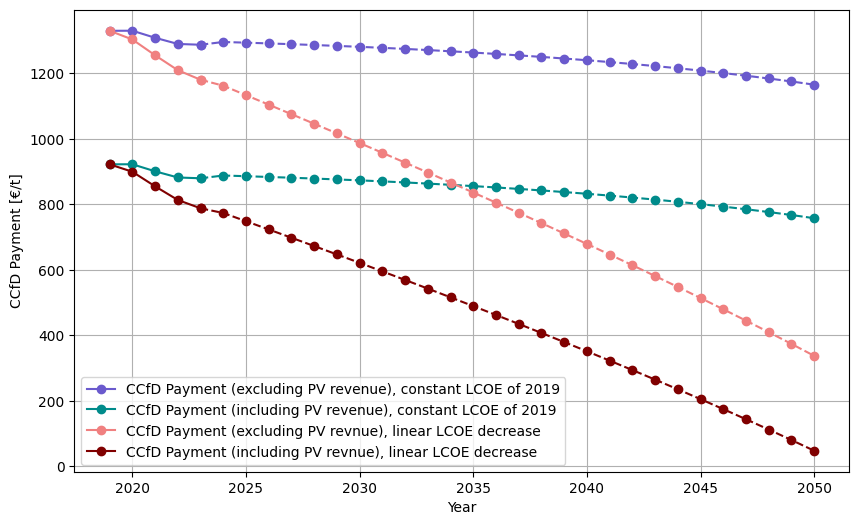